In [0]:
!pip install imbalanced-learn lightgbm --quiet

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
!pip install seaborn
!pip install xgboost

Looking in indexes: [REDACTED]
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Looking in indexes: [REDACTED]
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
"""Restart Python to load the new packages / reinicia o Python para carregar os pacotes novos."""

dbutils.library.restartPython()

In [0]:
"""Load gold tables and define features / carrega as tabelas gold e define as features."""
import time
import os
import json
import joblib

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from imblearn.over_sampling import SMOTENC
from sklearn.compose import ColumnTransformer
from imblearn.ensemble import BalancedRandomForestClassifier

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.metrics import classification_report, precision_recall_curve
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score

import mlflow
from mlflow import MlflowClient
from mlflow.models import infer_signature

In [0]:
# register models in unity catalog / registra modelos no unity catalog
mlflow.set_registry_uri("databricks-uc")
usuario = spark.sql("SELECT current_user()").first()[0]
mlflow.set_experiment(rf"/Users/{usuario}/cred_pred")

# train and test samples built in the gold layer / amostras de treino e teste criadas na camada gold
df_train = spark.table("workspace.gold.train").toPandas()
df_test = spark.table("workspace.gold.test").toPandas()

# low cardinality features only / somente features de baixa cardinalidade
num_cols = ["amt", "city_pop", "age", "distance_km", "hour", "day_of_week", "month"]
cat_cols = ["category", "state", "gender"]
features = cat_cols + num_cols

# features, target and test weights / features, alvo e pesos do teste
X_train, y_train = df_train[features], df_train["is_fraud"]
X_test, y_test = df_test[features], df_test["is_fraud"]
w_test = df_test["sample_weight"]

In [0]:
print(X_train.shape, X_test.shape)

(708650, 10) (377424, 10)


In [0]:
print(y_train.value_counts(normalize=True).round(4).to_dict())

{0: 0.7782, 1: 0.2218}


In [0]:
# categorical codes in columns 0 to 2, scaled numerics after / códigos categóricos nas colunas 0 a 2, numéricas padronizadas depois
prep = ColumnTransformer([
    ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), cat_cols),
    ("num", StandardScaler(), num_cols),
])
idx_cat = list(range(len(cat_cols)))

# shared lightgbm parameters / parâmetros do lightgbm compartilhados
params = dict(
    n_estimators=300, learning_rate=0.05, num_leaves=63,
    subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbose=-1,
)

In [0]:
# categorical codes first, scaled numerics after / códigos categóricos primeiro, numéricas padronizadas depois
prep = ColumnTransformer([
    ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), cat_cols),
    ("num", StandardScaler(), num_cols),
])
X_tr_enc = prep.fit_transform(X_train)
X_te_enc = prep.transform(X_test)
idx_cat = list(range(len(cat_cols)))

# fraud grows to 50% of the legitimate count / a fraude cresce até 50% da quantidade de legítimas
smote = SMOTENC(categorical_features=idx_cat, sampling_strategy=0.5, k_neighbors=5, random_state=42)
X_res, y_res = smote.fit_resample(X_tr_enc, y_train)
smote

(708650, 10) -> (827169, 10)


In [0]:
print(X_tr_enc.shape, "->", X_res.shape)

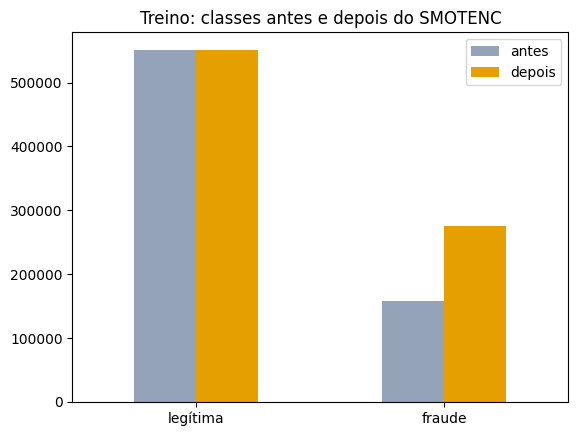

,antes,depois
legítima,551446,551446
fraude,157204,275723


In [0]:
"""Class balance before and after SMOTENC / balanceamento das classes antes e depois do SMOTENC."""

# counts per class on the train set / contagem por classe no treino
antes = y_train.value_counts().sort_index()
depois = pd.Series(y_res).value_counts().sort_index()
contagens = pd.DataFrame({"antes": antes.values, "depois": depois.values}, index=["legítima", "fraude"])

contagens.plot.bar(color=["#94A3B8", "#E69F00"], rot=0)
plt.title("Treino: classes antes e depois do SMOTENC")
plt.show()
contagens

In [0]:
# one-hot for the linear model, ordinal codes for the tree models / one-hot para o modelo linear, códigos ordinais para os modelos de árvore
prep_linear = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", StandardScaler(), num_cols),
])
prep_arvore = ColumnTransformer([
    ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), cat_cols),
    ("num", "passthrough", num_cols),
])
preps = {"linear": prep_linear, "arvore": prep_arvore}

# set a number to test the loop on a subsample / defina um número para testar o loop em uma subamostra
n_teste = None
if n_teste:
    idx = X_train.sample(n_teste, random_state=42).index
    X_fit, y_fit = X_train.loc[idx], y_train.loc[idx]
else:
    X_fit, y_fit = X_train, y_train

# negative to positive ratio for xgboost / razão entre negativos e positivos para o xgboost
peso_pos = (y_fit == 0).sum() / (y_fit == 1).sum()

In [0]:
from lightgbm import LGBMClassifier
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import AdaBoostClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# one-hot on the categorical codes for the linear model / one-hot nos códigos categóricos para o modelo linear
reg_log = Pipeline([
    ("ohe", ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), idx_cat)], remainder="passthrough")),
    ("classifier", LogisticRegression(max_iter=300)),
])

modelos_smote = {
    "regressao_logistica": reg_log,
    "arvore_decisao": DecisionTreeClassifier(max_depth=12, min_samples_leaf=50, random_state=42),
    "random_forest": RandomForestClassifier(n_estimators=100, max_depth=12, min_samples_leaf=20, n_jobs=-1, random_state=42),
    "extra_trees": ExtraTreesClassifier(n_estimators=100, max_depth=14, min_samples_leaf=20, n_jobs=-1, random_state=42),
    "hist_gradient_boosting": HistGradientBoostingClassifier(max_iter=200, learning_rate=0.1, random_state=42),
    "lightgbm": LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=63, subsample=0.8, subsample_freq=1, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbose=-1),
    "xgboost": XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=8, subsample=0.8, colsample_bytree=0.8, tree_method="hist", n_jobs=-1, random_state=42),
    "adaboost": AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3), n_estimators=100, random_state=42),
}

# set a number to test the loop on a subsample / defina um número para testar o loop em uma subamostra
n_teste = None
if n_teste:
    idx = np.random.default_rng(42).choice(len(X_res), n_teste, replace=False)
    X_fit, y_fit = X_res[idx], np.asarray(y_res)[idx]
else:
    X_fit, y_fit = X_res, y_res
print(len(modelos_smote), "modelos |", X_fit.shape)

8 modelos | (827169, 10)


In [0]:
"""Train and evaluate the 8 models in a loop / treina e avalia os 8 modelos em um loop."""

# fitted pipelines, test probabilities and metric rows / pipelines treinados, probabilidades de teste e linhas de métricas
treinados_smote = {}
probas_smote = {}
linhas_smote = []

for nome, modelo in modelos_smote.items():
    try:
        # fit on resampled train, predict on the untouched test / treina no treino balanceado, prevê no teste intacto
        inicio = time.time()
        modelo.fit(X_fit, y_fit)
        segundos = time.time() - inicio
        proba = modelo.predict_proba(X_te_enc)[:, 1]

        # weighted metrics restore the real class proportion / métricas ponderadas restauram a proporção real das classes
        pr_auc = average_precision_score(y_test, proba, sample_weight=w_test)
        roc_auc = roc_auc_score(y_test, proba, sample_weight=w_test)
        precisao, recall, _ = precision_recall_curve(y_test, proba, sample_weight=w_test)
        recall_p90 = recall[precisao >= 0.90].max() if (precisao >= 0.90).any() else 0.0

        with mlflow.start_run(run_name=f"{nome}_smotenc"):
            mlflow.log_params({"modelo": nome, "balanceamento": "smotenc"})
            mlflow.log_metrics({"pr_auc_w": pr_auc, "roc_auc_w": roc_auc, "recall_at_p90_w": recall_p90, "fit_seconds": segundos})

        treinados_smote[nome] = modelo
        probas_smote[nome] = proba
        linhas_smote.append({"modelo": nome, "pr_auc_w": pr_auc, "roc_auc_w": roc_auc, "recall_p90_w": recall_p90, "segundos": segundos})
        print(nome, round(pr_auc, 4), f"{segundos:.0f}s")
    except Exception as erro:
        print("FAILED:", nome, erro)

2026/10/08 20:08:44 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/10/08 20:08:44 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/10/08 20:08:44 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


regressao_logistica 0.0039 2s


2026/10/08 20:08:51 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/10/08 20:08:51 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/10/08 20:08:51 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


arvore_decisao 0.0106 6s


2026/10/08 20:09:10 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/10/08 20:09:10 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/10/08 20:09:10 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


...

lightgbm 0.1791 5s


2026/10/08 20:09:37 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/10/08 20:09:37 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/10/08 20:09:37 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


xgboost 0.2044 5s


2026/10/08 20:12:46 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/10/08 20:12:46 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/10/08 20:12:47 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


adaboost 0.5883 187s


In [0]:
"""Permutation importance for the 8 models / importância por permutação dos 8 modelos."""

from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline

# wrap each model with the fitted preprocessor so it accepts raw columns / embrulha cada modelo com o pré-processador treinado para aceitar colunas brutas
# swap treinados_smote for treinados to use the class_weight run / troque treinados_smote por treinados para usar a execução do class_weight
pipes = {nome: Pipeline([("prep", prep), ("model", modelo)]) for nome, modelo in treinados_smote.items()}

# test subsample keeps the loop fast / subamostra do teste mantém o loop rápido
amostra_teste = X_test.sample(50_000, random_state=42)
y_amostra = y_test.loc[amostra_teste.index]
w_amostra = w_test.loc[amostra_teste.index]

importancias = {}
for nome, pipe in pipes.items():
    # drop in weighted PR-AUC when each column is shuffled / queda na PR-AUC ponderada ao embaralhar cada coluna
    r = permutation_importance(
        pipe, amostra_teste, y_amostra,
        scoring="average_precision", sample_weight=w_amostra,
        n_repeats=3, random_state=42, n_jobs=1,
    )
    importancias[nome] = pd.Series(r.importances_mean, index=amostra_teste.columns)
    print(nome, "ok")

regressao_logistica ok
arvore_decisao ok
random_forest ok
extra_trees ok
hist_gradient_boosting ok


/opt/databricks-environments/databricks-ai/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/databricks-environments/databricks-ai/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/databricks-environments/databricks-ai/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/databricks-environments/databricks-ai/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/databricks-environments/databricks-ai/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWa

lightgbm ok
xgboost ok
adaboost ok


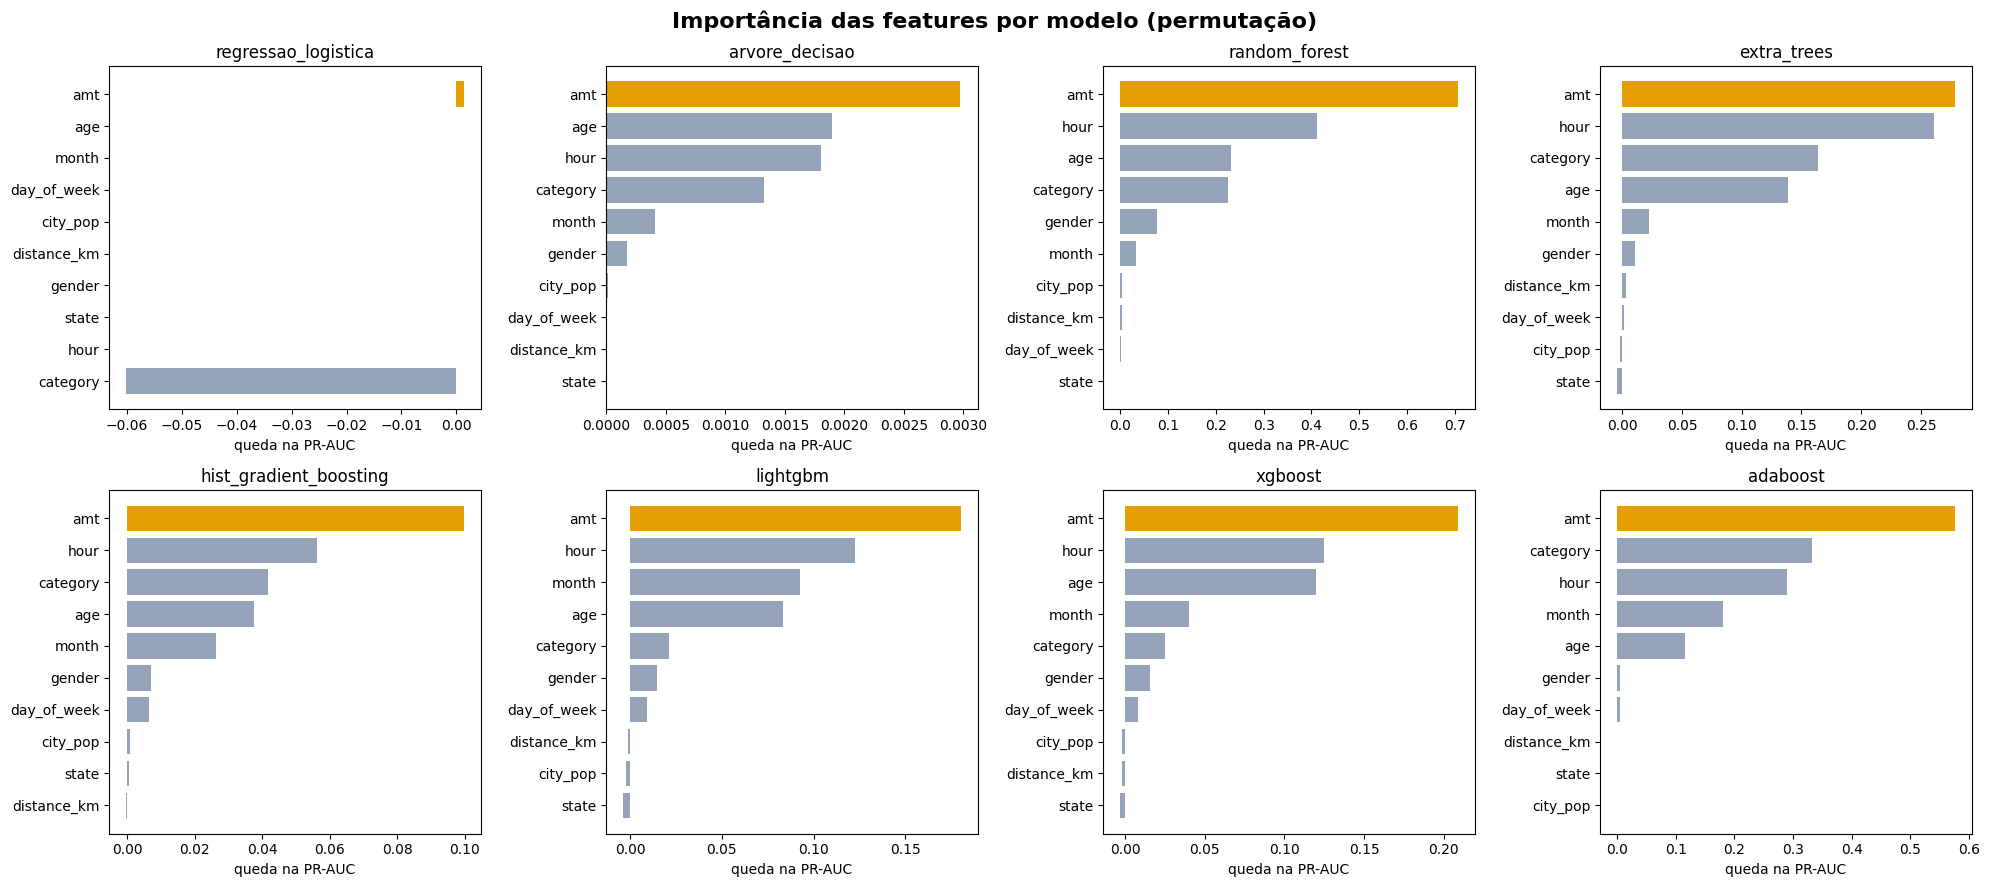

In [0]:
"""Feature importance plot for each model / gráfico de importância das features de cada modelo."""

import matplotlib.pyplot as plt

# one panel per model, top feature highlighted / um painel por modelo, feature líder destacada
fig, eixos = plt.subplots(2, 4, figsize=(20, 9))
for ax, (nome, imp) in zip(eixos.ravel(), importancias.items()):
    imp = imp.sort_values()
    cores = ["#94A3B8"] * (len(imp) - 1) + ["#E69F00"]
    ax.barh(imp.index, imp.values, color=cores)
    ax.set_title(nome)
    ax.set_xlabel("queda na PR-AUC")

plt.suptitle("Importância das features por modelo (permutação)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

regressao_logistica,arvore_decisao,random_forest,extra_trees,hist_gradient_boosting,lightgbm,xgboost,adaboost,media
0.976,0.346,0.417,0.317,0.361,0.344,0.385,0.383,0.441
0.0,0.21,0.243,0.297,0.203,0.234,0.231,0.192,0.201
0.013,0.22,0.136,0.158,0.136,0.159,0.221,0.077,0.14
0.0,0.154,0.134,0.186,0.151,0.041,0.046,0.221,0.117
0.008,0.047,0.02,0.026,0.095,0.177,0.074,0.12,0.071
0.0,0.02,0.046,0.012,0.025,0.028,0.029,0.004,0.02
0.003,0.0,0.001,0.001,0.023,0.017,0.015,0.003,0.008
0.0,0.001,0.002,0.0,0.003,0.0,0.0,0.0,0.001
0.0,0.0,0.002,0.004,0.0,0.0,0.0,0.0,0.001
0.0,0.0,0.0,0.0,0.002,0.0,0.0,0.0,0.0


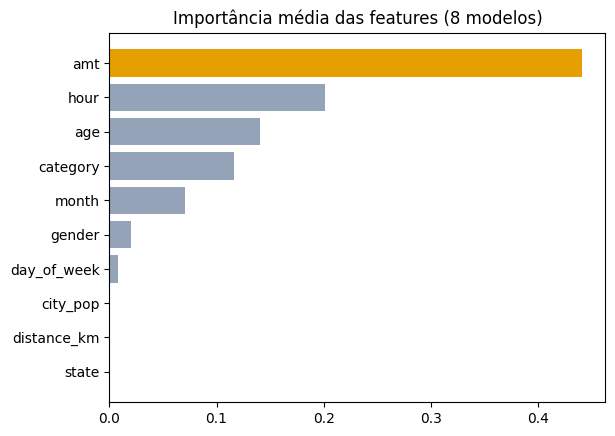

In [0]:
"""Average importance across the 8 models / importância média entre os 8 modelos."""

# normalize each model so scales are comparable / normaliza cada modelo para as escalas ficarem comparáveis
tabela_imp = pd.DataFrame(importancias).clip(lower=0)
tabela_imp = tabela_imp / tabela_imp.sum()
tabela_imp["media"] = tabela_imp.mean(axis=1)
tabela_imp = tabela_imp.sort_values("media", ascending=False)
display(tabela_imp.round(3))

# bars sorted by mean importance / barras ordenadas pela importância média
dados = tabela_imp["media"].sort_values()
cores = ["#94A3B8"] * (len(dados) - 1) + ["#E69F00"]
plt.barh(dados.index, dados.values, color=cores)
plt.title("Importância média das features (8 modelos)")
plt.show()

In [0]:
"""Thresholds per model from the weighted curve / limiares por modelo a partir da curva ponderada."""

# swap to probas_cw for the class_weight run / troque para probas_cw para a execução do class_weight
probas_alvo = probas_smote

limiares = {}
for nome, proba in probas_alvo.items():
    precisao, recall, lim = precision_recall_curve(y_test, proba, sample_weight=w_test)

    # lowest threshold that keeps weighted precision at 90% / menor limiar que mantém a precisão ponderada em 90%
    ok = precisao[:-1] >= 0.90
    lim_p90 = lim[ok][0] if ok.any() else 0.5

    # threshold that maximizes weighted F1 / limiar que maximiza o F1 ponderado
    f1 = 2 * precisao[:-1] * recall[:-1] / np.clip(precisao[:-1] + recall[:-1], 1e-12, None)
    limiares[nome] = {"p90": lim_p90, "f1": lim[f1.argmax()]}

pd.DataFrame(limiares).T.round(4)

,p90,f1
regressao_logistica,0.5000,0.9999
arvore_decisao,0.5000,0.8471
random_forest,0.9669,0.9593
extra_trees,0.9420,0.8935
hist_gradient_boosting,1.0000,0.9999
lightgbm,1.0000,0.9999
xgboost,1.0000,1.0000
adaboost,0.6404,0.6384


In [0]:
"""Classification report of each model in a loop / classification report de cada modelo em um loop."""

# "f1" balances precision and recall, "p90" fixes precision at 90% / "f1" equilibra precisão e recall, "p90" fixa a precisão em 90%
criterio = "f1"

for nome, proba in probas_alvo.items():
    lim = limiares[nome][criterio]
    pred = (proba >= lim).astype(int)
    print(f"{nome} | limiar {criterio} = {lim:.4f}")
    print(classification_report(y_test, pred, target_names=["legítima", "fraude"], sample_weight=w_test, digits=4, zero_division=0))

regressao_logistica | limiar f1 = 0.9999
              precision    recall  f1-score   support

    legítima     0.9953    0.9954    0.9954 6894060.0
      fraude     0.0148    0.0145    0.0147   32721.0

    accuracy                         0.9908 6926781.0
   macro avg     0.5051    0.5050    0.5050 6926781.0
weighted avg     0.9907    0.9908    0.9907 6926781.0

arvore_decisao | limiar f1 = 0.8471
              precision    recall  f1-score   support

    legítima     0.9995    0.6888    0.8156 6894060.0
      fraude     0.0141    0.9344    0.0277   32721.0

    accuracy                         0.6900 6926781.0
   macro avg     0.5068    0.8116    0.4216 6926781.0
weighted avg     0.9949    0.6900    0.8119 6926781.0

random_forest | limiar f1 = 0.9593
              precision    recall  f1-score   support

    legítima     0.9981    0.9996    0.9988 6894060.0
      fraude     0.8721    0.5960    0.7081   32721.0

    accuracy                         0.9977 6926781.0
   macro avg    

In [0]:
"""Fraud class summary for all models / resumo da classe fraude de todos os modelos."""

linhas_rel = []
for nome, proba in probas_alvo.items():
    pred = (proba >= limiares[nome][criterio]).astype(int)
    rel = classification_report(
        y_test, pred, target_names=["legítima", "fraude"],
        sample_weight=w_test, output_dict=True, zero_division=0,
    )
    linhas_rel.append({
        "modelo": nome,
        "precisao": rel["fraude"]["precision"],
        "recall": rel["fraude"]["recall"],
        "f1": rel["fraude"]["f1-score"],
        "alarme_falso": 1 - rel["legítima"]["recall"],
    })

# sorted by f1 / ordenado pelo f1
tabela_rel = pd.DataFrame(linhas_rel).sort_values("f1", ascending=False).reset_index(drop=True)
display(tabela_rel.round(4))

modelo,precisao,recall,f1,alarme_falso
random_forest,0.8721,0.596,0.7081,4.0E-4
adaboost,0.8824,0.468,0.6116,3.0E-4
extra_trees,0.4134,0.2792,0.3333,0.0019
xgboost,0.339,0.1994,0.2511,0.0018
lightgbm,0.2529,0.1914,0.2179,0.0027
hist_gradient_boosting,0.122,0.2029,0.1524,0.0069
arvore_decisao,0.0141,0.9344,0.0277,0.3112
regressao_logistica,0.0148,0.0145,0.0147,0.0046


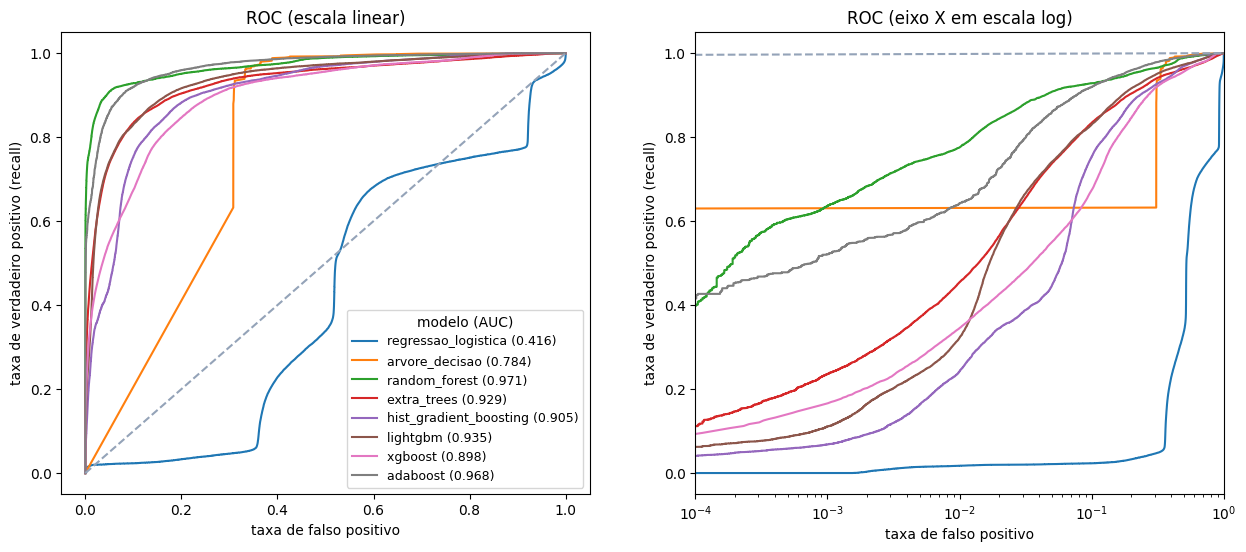

In [0]:
"""ROC curves of all models / curvas ROC de todos os modelos."""
from sklearn.metrics import (
    auc,
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_curve,
)

# linear scale on the left, log scale on the right / escala linear à esquerda, escala log à direita
fig, eixos = plt.subplots(1, 2, figsize=(15, 6))

for nome, proba in probas_alvo.items():
    fpr, tpr, _ = roc_curve(y_test, proba, sample_weight=w_test)
    rotulo = f"{nome} ({auc(fpr, tpr):.3f})"
    for ax in eixos:
        ax.plot(fpr, tpr, label=rotulo)

# random classifier reference / referência do classificador aleatório
for ax in eixos:
    ax.plot([0, 1], [0, 1], linestyle="--", color="#94A3B8")
    ax.set_xlabel("taxa de falso positivo")
    ax.set_ylabel("taxa de verdadeiro positivo (recall)")

eixos[0].set_title("ROC (escala linear)")
eixos[1].set_xscale("log")
eixos[1].set_xlim(1e-4, 1)
eixos[1].set_title("ROC (eixo X em escala log)")
eixos[0].legend(title="modelo (AUC)", fontsize=9, loc="lower right")
plt.show()

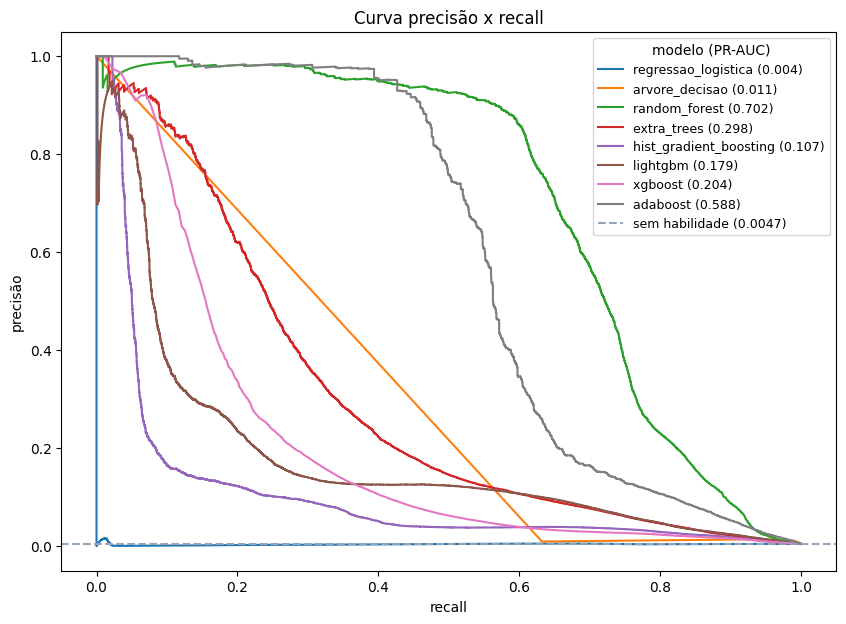

In [0]:
"""Precision-recall curves of all models / curvas de precisão e recall de todos os modelos."""

# real fraud rate in the test set, restored by the weights / taxa real de fraude no teste, restaurada pelos pesos
taxa_real = (y_test * w_test).sum() / w_test.sum()

plt.figure(figsize=(10, 7))
for nome, proba in probas_alvo.items():
    precisao, recall, _ = precision_recall_curve(y_test, proba, sample_weight=w_test)
    ap = average_precision_score(y_test, proba, sample_weight=w_test)
    plt.plot(recall, precisao, label=f"{nome} ({ap:.3f})")

# no-skill baseline / linha de base sem habilidade
plt.axhline(taxa_real, linestyle="--", color="#94A3B8", label=f"sem habilidade ({taxa_real:.4f})")
plt.xlabel("recall")
plt.ylabel("precisão")
plt.title("Curva precisão x recall")
plt.legend(title="modelo (PR-AUC)", fontsize=9)
plt.show()

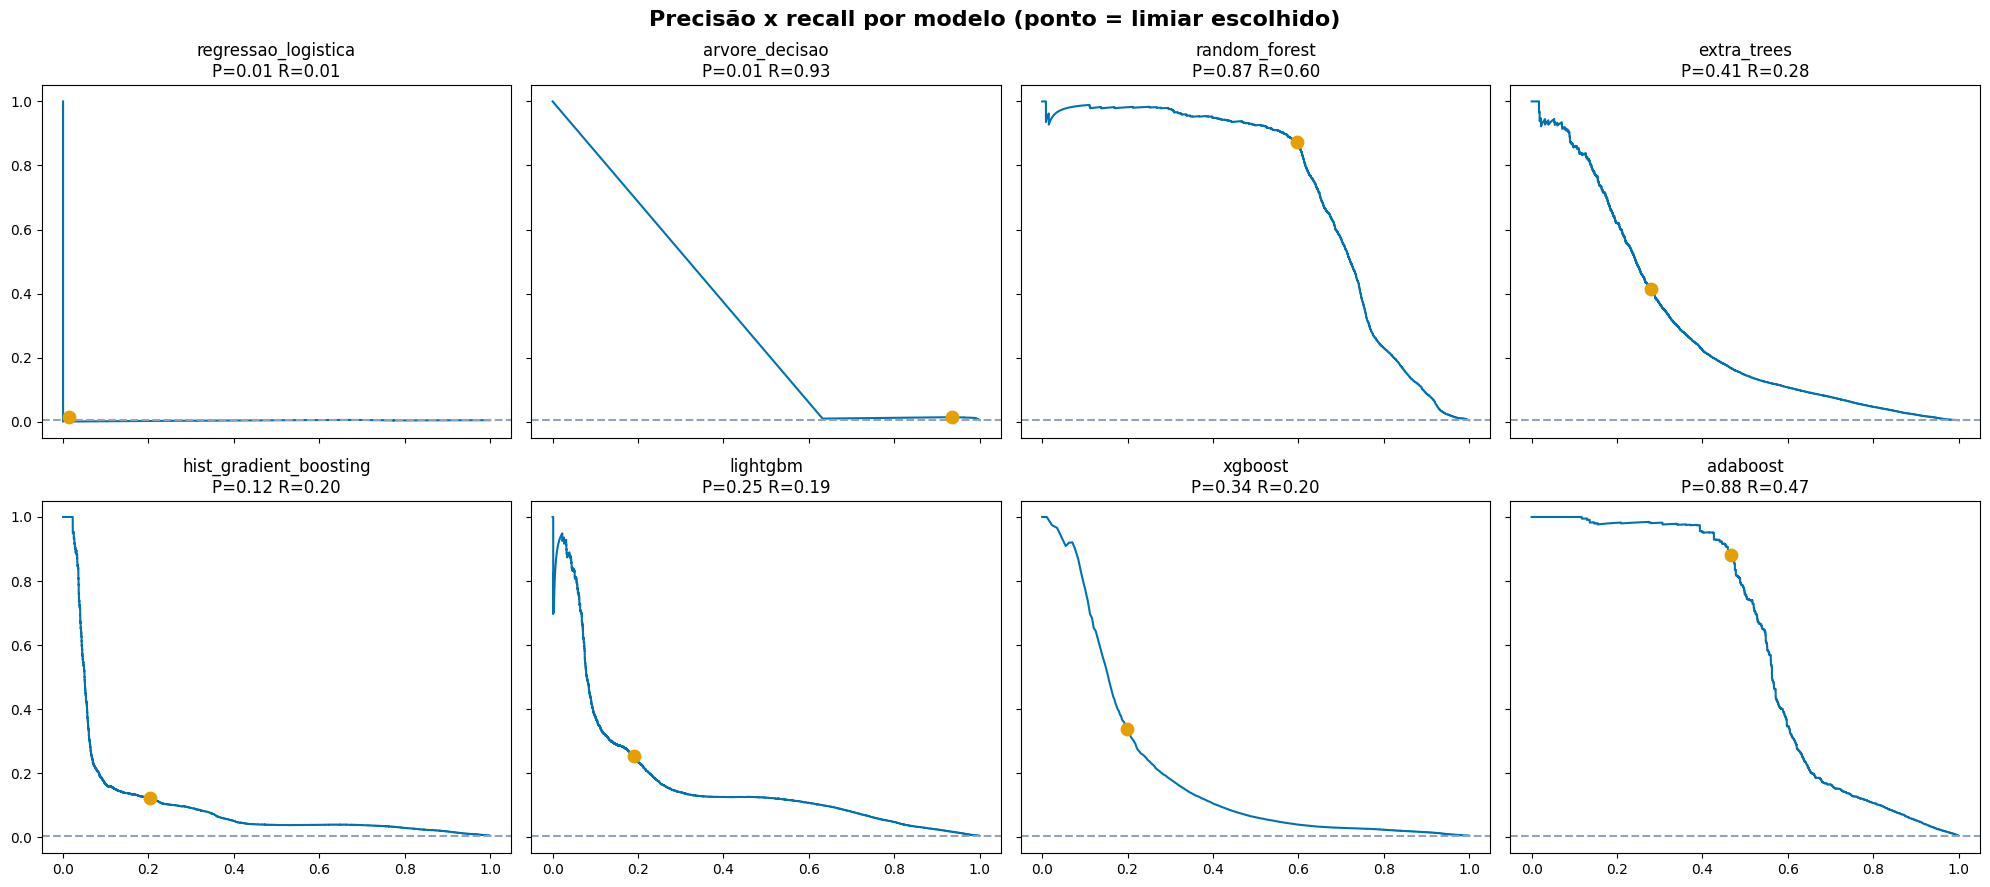

In [0]:
"""One precision-recall panel per model / um painel de precisão e recall por modelo."""

# the threshold criterion from the classification report cell / o critério de limiar da célula do classification report
criterio = "f1"

fig, eixos = plt.subplots(2, 4, figsize=(20, 9), sharex=True, sharey=True)
for ax, (nome, proba) in zip(eixos.ravel(), probas_alvo.items()):
    precisao, recall, _ = precision_recall_curve(y_test, proba, sample_weight=w_test)
    ax.plot(recall, precisao, color="#0072B2")
    ax.axhline(taxa_real, linestyle="--", color="#94A3B8")

    # operating point at the chosen threshold / ponto de operação no limiar escolhido
    pred = (proba >= limiares[nome][criterio]).astype(int)
    p = precision_score(y_test, pred, sample_weight=w_test, zero_division=0)
    r = recall_score(y_test, pred, sample_weight=w_test)
    ax.scatter(r, p, color="#E69F00", s=80, zorder=3)
    ax.set_title(f"{nome}\nP={p:.2f} R={r:.2f}")

plt.suptitle("Precisão x recall por modelo (ponto = limiar escolhido)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

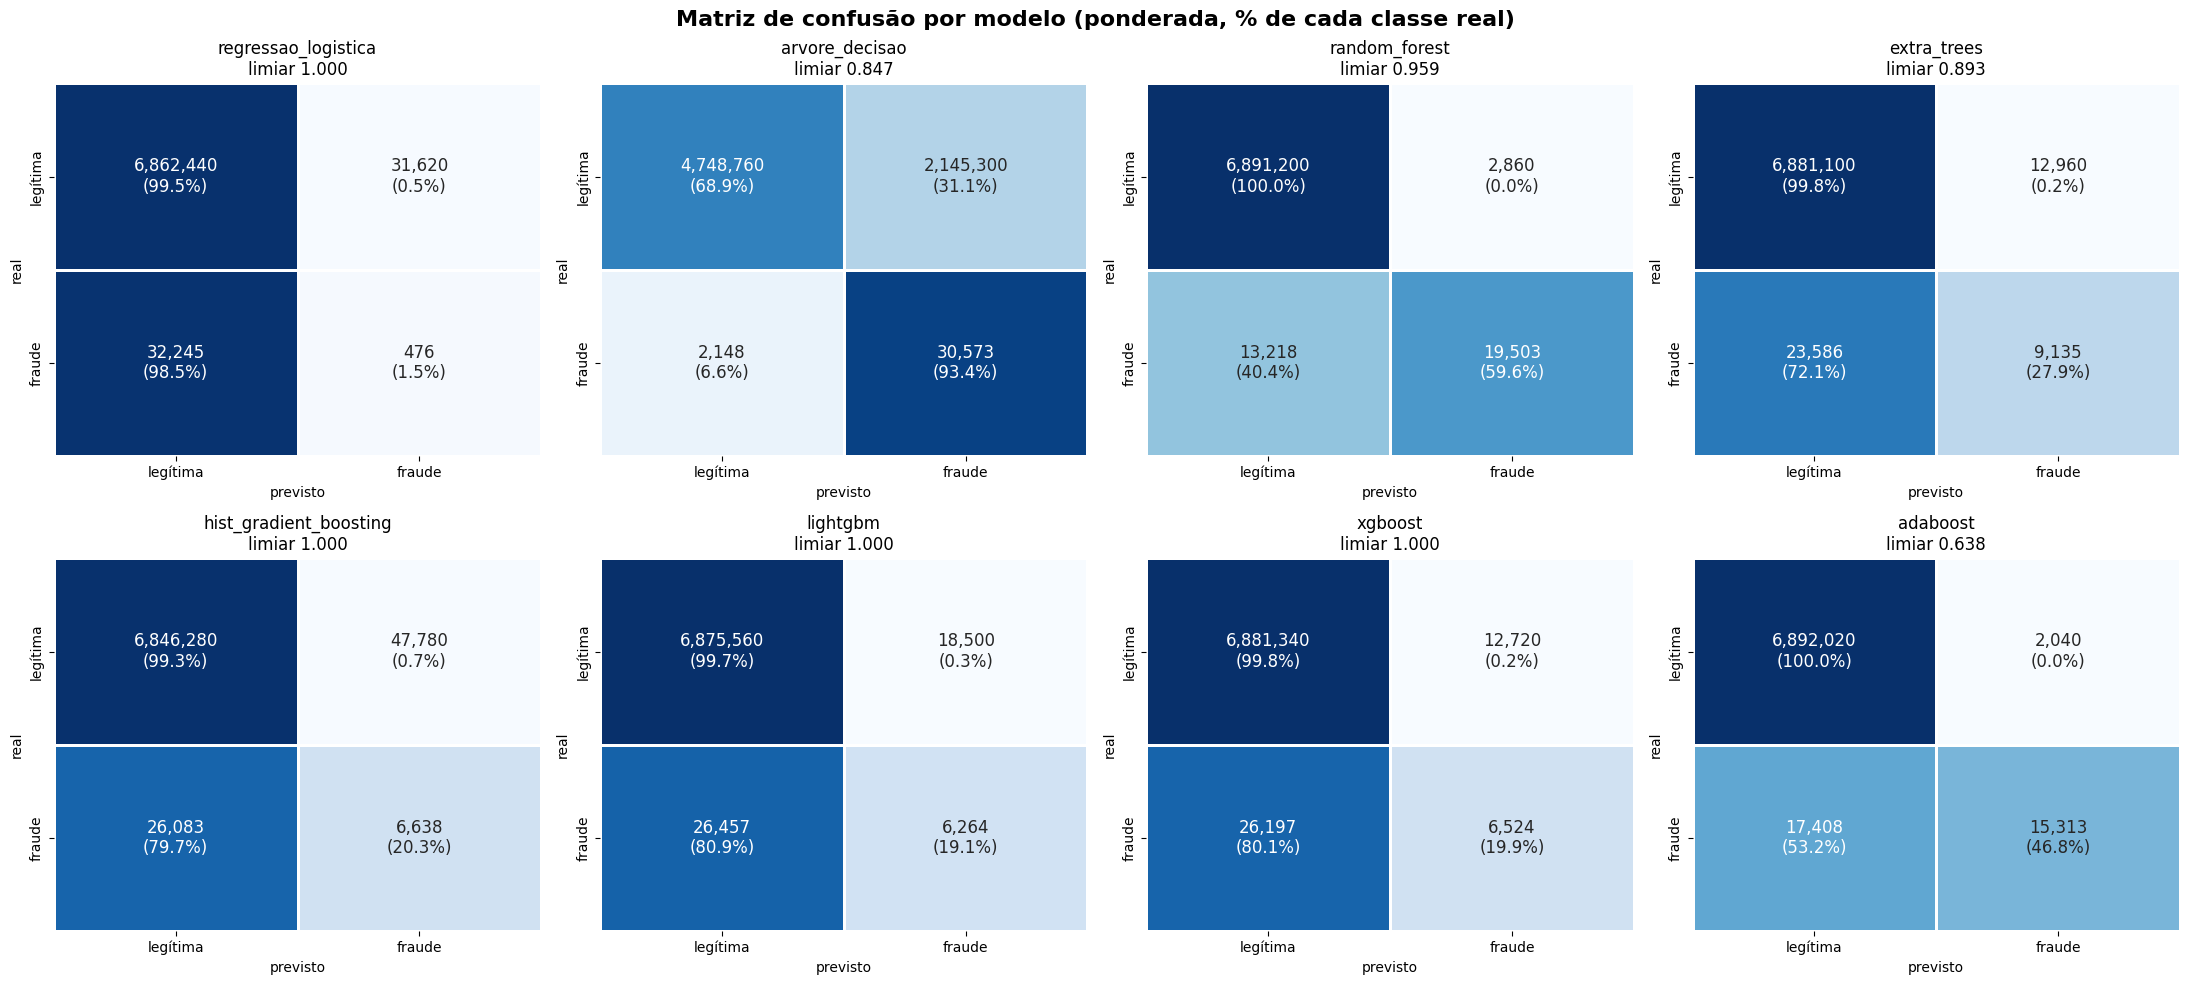

In [0]:
"""Confusion matrices of all models with seaborn / matrizes de confusão de todos os modelos com seaborn."""

# threshold criterion from the classification report cell, "f1" or "p90" / critério de limiar da célula do classification report, "f1" ou "p90"
criterio = "f1"
rotulos = ["legítima", "fraude"]

fig, eixos = plt.subplots(2, 4, figsize=(22, 10))
for ax, (nome, proba) in zip(eixos.ravel(), probas_alvo.items()):
    # predictions at the model's own threshold / previsões no limiar próprio do modelo
    lim = limiares[nome][criterio]
    pred = (proba >= lim).astype(int)

    # weighted counts and percentage of each real class / contagens ponderadas e percentual de cada classe real
    cm = confusion_matrix(y_test, pred, sample_weight=w_test)
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

    # cell label with estimated count and row percentage / rótulo da célula com contagem estimada e percentual da linha
    anot = np.array([[f"{cm[i, j]:,.0f}\n({cm_pct[i, j]:.1f}%)" for j in range(2)] for i in range(2)])

    sns.heatmap(
        cm_pct, annot=anot, fmt="", cmap="Blues", vmin=0, vmax=100, cbar=False,
        xticklabels=rotulos, yticklabels=rotulos, linewidths=1, linecolor="white",
        annot_kws={"fontsize": 12}, ax=ax,
    )
    ax.set_title(f"{nome}\nlimiar {lim:.3f}")
    ax.set_xlabel("previsto")
    ax.set_ylabel("real")

plt.suptitle("Matriz de confusão por modelo (ponderada, % de cada classe real)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

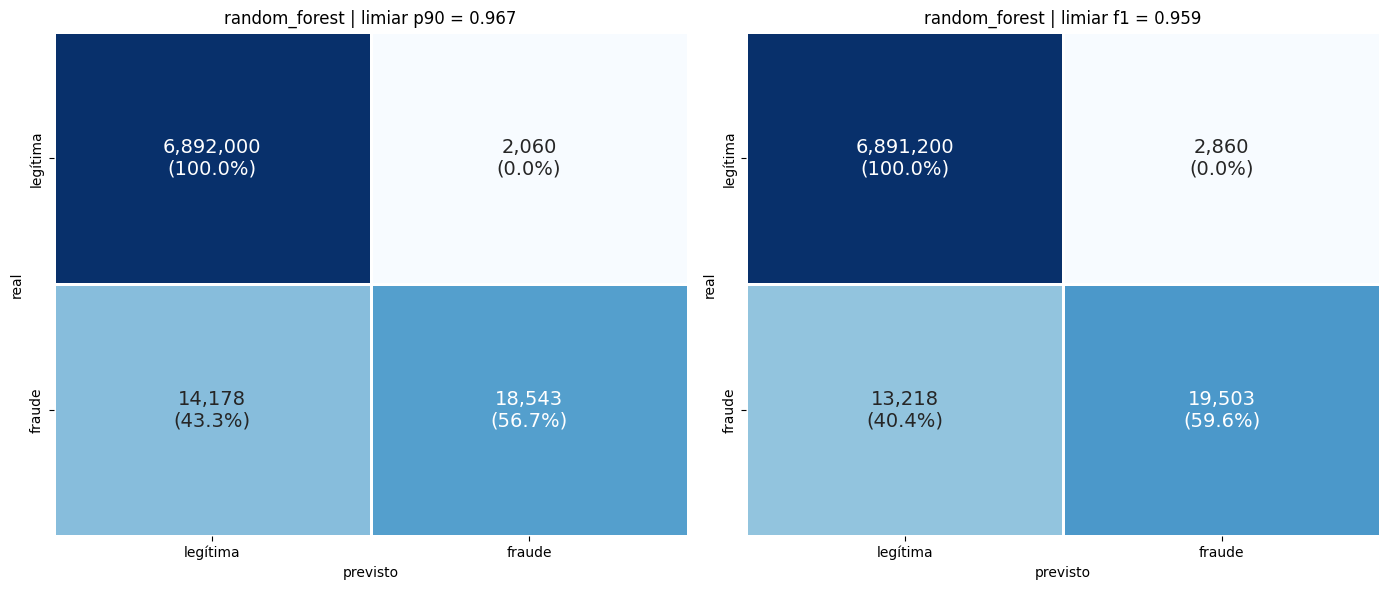

In [0]:
"""Best model with both thresholds / melhor modelo com os dois limiares."""

# best model from the f1 summary table / melhor modelo da tabela de resumo do f1
melhor = tabela_rel.loc[0, "modelo"]

fig, eixos = plt.subplots(1, 2, figsize=(14, 6))
for ax, crit in zip(eixos, ["p90", "f1"]):
    lim = limiares[melhor][crit]
    pred = (probas_alvo[melhor] >= lim).astype(int)
    cm = confusion_matrix(y_test, pred, sample_weight=w_test)
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
    anot = np.array([[f"{cm[i, j]:,.0f}\n({cm_pct[i, j]:.1f}%)" for j in range(2)] for i in range(2)])
    sns.heatmap(cm_pct, annot=anot, fmt="", cmap="Blues", vmin=0, vmax=100, cbar=False,
                xticklabels=rotulos, yticklabels=rotulos, linewidths=1, linecolor="white",
                annot_kws={"fontsize": 14}, ax=ax)
    ax.set_title(f"{melhor} | limiar {crit} = {lim:.3f}")
    ax.set_xlabel("previsto")
    ax.set_ylabel("real")

plt.tight_layout()
plt.show()

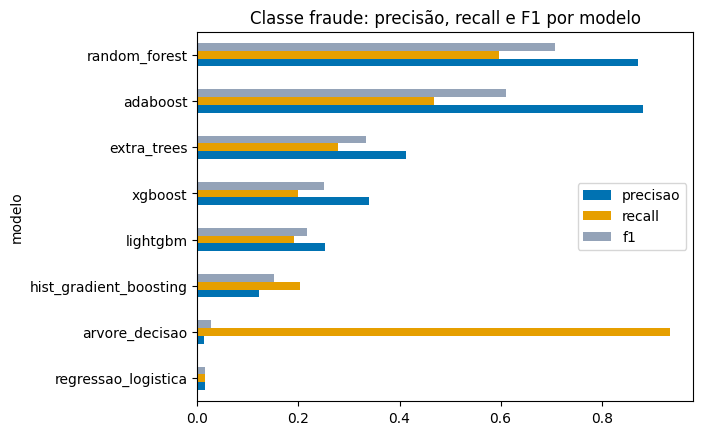

In [0]:
"""Plot precision, recall and F1 by model / gráfico de precisão, recall e F1 por modelo."""

# grouped bars sorted by f1 / barras agrupadas ordenadas pelo f1
dados = tabela_rel.sort_values("f1").set_index("modelo")[["precisao", "recall", "f1"]]
dados.plot.barh(color=["#0072B2", "#E69F00", "#94A3B8"])
plt.title("Classe fraude: precisão, recall e F1 por modelo")
plt.show()

In [0]:
"""List saved files with sizes / lista os arquivos salvos com os tamanhos."""

# walk the folder and print sizes in MB / percorre a pasta e imprime os tamanhos em MB
for raiz, _, arquivos in os.walk(pasta_modelos):
    for arq in sorted(arquivos):
        caminho = rf"{raiz}/{arq}"
        print(round(os.path.getsize(caminho) / 1024**2, 1), "MB |", caminho.replace(pasta_modelos, "..."))

0.0 MB | .../classification_report_smotenc.csv
0.0 MB | .../limiares_smotenc.json
0.0 MB | .../metricas_smotenc.csv


In [0]:
"""Point MLflow to the workspace folder / aponta o MLflow para a pasta do workspace."""

import mlflow

# experiment path has no /Workspace prefix / o caminho do experimento não leva o prefixo /Workspace
pasta_mlflow = r"/Users/rafaelhenriquegallo@gmail.com/Delta lake (MLops)/mlflow"
experimento = mlflow.set_experiment(rf"{pasta_mlflow}/cred_pred")
print(experimento.experiment_id, experimento.name)

2026/10/08 20:16:42 INFO mlflow.tracking.fluent: Experiment with name '/Users/rafaelhenriquegallo@gmail.com/Delta lake (MLops)/mlflow/cred_pred' does not exist. Creating a new experiment.


1142565039167818 /Users/rafaelhenriquegallo@gmail.com/Delta lake (MLops)/mlflow/cred_pred


In [0]:
"""Save the top models in MLflow format / salva os melhores modelos em formato MLflow."""

import os
import shutil
from mlflow.models import infer_signature
from sklearn.pipeline import Pipeline

# destination folder as a filesystem path / pasta de destino como caminho de sistema de arquivos
pasta_fs = r"/Workspace/Users/rafaelhenriquegallo@gmail.com/Delta lake (MLops)/mlflow/modelos"
os.makedirs(pasta_fs, exist_ok=True)

# top 3 smotenc models by weighted PR-AUC / 3 melhores modelos smotenc pela PR-AUC ponderada
top = resumo_smote["modelo"].head(3).tolist()
exemplo = X_train.head(100)

for nome in top:
    # full pipeline accepts the original columns / o pipeline completo aceita as colunas originais
    pipe = Pipeline([("prep", prep), ("model", treinados_smote[nome])])
    destino = rf"{pasta_fs}/smotenc_{nome}"

    # save_model fails if the folder already exists / o save_model falha se a pasta já existir
    if os.path.exists(destino):
        shutil.rmtree(destino)
    mlflow.sklearn.save_model(
        pipe,
        destino,
        signature=infer_signature(exemplo, pipe.predict_proba(exemplo)),
        input_example=exemplo.head(5),
        pyfunc_predict_fn="predict_proba",
    )
    print("saved:", destino)

/opt/databricks-environments/databricks-ai/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


saved: /Workspace/Users/rafaelhenriquegallo@gmail.com/Delta lake (MLops)/mlflow/modelos/smotenc_random_forest


/opt/databricks-environments/databricks-ai/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


saved: /Workspace/Users/rafaelhenriquegallo@gmail.com/Delta lake (MLops)/mlflow/modelos/smotenc_adaboost


/opt/databricks-environments/databricks-ai/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


saved: /Workspace/Users/rafaelhenriquegallo@gmail.com/Delta lake (MLops)/mlflow/modelos/smotenc_extra_trees


In [0]:
"""Reload a saved MLflow model and check it / recarrega um modelo MLflow salvo e confere."""

import numpy as np

# load through the generic pyfunc interface / carrega pela interface genérica pyfunc
nome = top[0]
carregado = mlflow.pyfunc.load_model(rf"{pasta_fs}/smotenc_{nome}")
novas = carregado.predict(X_test.head(5))
print(novas)

[[0.80363367 0.19636633]
 [0.93232511 0.06767489]
 [0.79784501 0.20215499]
 [0.51841622 0.48158378]
 [0.88753701 0.11246299]]


In [0]:
print(np.allclose(np.asarray(novas).reshape(len(novas), -1)[:, -1], probas_smote[nome][:5]))

True


In [0]:
"""Check the trained models are still in memory / confere se os modelos treinados ainda estão na memória."""

# names the saving cell depends on / nomes dos quais a célula de salvamento depende
necessarias = ["treinados_smote", "probas_smote", "linhas_smote", "prep", "X_test"]
print({nome: nome in globals() for nome in necessarias})
print(list(treinados_smote.keys()) if "treinados_smote" in globals() else "treinados_smote não existe")

{'treinados_smote': True, 'probas_smote': True, 'linhas_smote': True, 'prep': True, 'X_test': True}
['regressao_logistica', 'arvore_decisao', 'random_forest', 'extra_trees', 'hist_gradient_boosting', 'lightgbm', 'xgboost', 'adaboost']


In [0]:
"""Save the already trained models / salva os modelos já treinados."""

# destination folder for the smotenc models / pasta de destino dos modelos smotenc
pasta_modelos = r"/Workspace/Users/rafaelhenriquegallo@gmail.com/Delta lake (MLops)/models/smotenc"
os.makedirs(pasta_modelos, exist_ok=True)

for nome, modelo in treinados_smote.items():
    # wrap with the fitted preprocessor so the file accepts raw columns / embrulha com o pré-processador treinado para o arquivo aceitar colunas brutas
    pipe_completo = Pipeline([("prep", prep), ("model", modelo)])
    caminho = rf"{pasta_modelos}/{nome}.joblib"
    joblib.dump(pipe_completo, caminho, compress=3)
    print(nome, f"{os.path.getsize(caminho) / 1024**2:.1f} MB")

# metrics table next to the models / tabela de métricas junto dos modelos
resumo_smote = pd.DataFrame(linhas_smote).sort_values("pr_auc_w", ascending=False).reset_index(drop=True)
resumo_smote.to_csv(rf"{pasta_modelos}/metricas_smotenc.csv", index=False)
display(resumo_smote.round(4))

regressao_logistica 0.0 MB
arvore_decisao 0.0 MB
random_forest 5.8 MB
extra_trees 12.9 MB
hist_gradient_boosting 0.3 MB
lightgbm 0.9 MB
xgboost 1.1 MB
adaboost 0.1 MB


modelo,pr_auc_w,roc_auc_w,recall_p90_w,segundos
random_forest,0.7025,0.9705,0.5667,17.9886
adaboost,0.5883,0.9683,0.4595,186.8048
extra_trees,0.2978,0.9291,0.0885,8.2041
xgboost,0.2044,0.8981,0.0771,4.9255
lightgbm,0.1791,0.935,0.0323,5.3175
hist_gradient_boosting,0.1067,0.9049,0.0292,4.2168
arvore_decisao,0.0106,0.7841,0.0,6.0898
regressao_logistica,0.0039,0.4156,0.0,2.355


In [0]:
"""Reload one saved model and check it / recarrega um modelo salvo e confere."""

# load from disk and predict on raw columns / carrega do disco e prevê em colunas brutas
carregado = joblib.load(rf"{pasta_modelos}/lightgbm.joblib")
novas = carregado.predict_proba(X_test.head(5))[:, 1]
print(np.allclose(novas, probas_smote["lightgbm"][:5]))

True


/opt/databricks-environments/databricks-ai/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [0]:
import joblib, lightgbm, numpy, pandas, sklearn

print(f"scikit-learn=={sklearn.__version__}")
print(f"lightgbm=={lightgbm.__version__}")
print(f"pandas=={pandas.__version__}")
print(f"numpy=={numpy.__version__}")
print(f"joblib=={joblib.__version__}")

scikit-learn==1.6.1
lightgbm==4.6.0
pandas==2.2.3
numpy==2.1.3
joblib==1.4.2
